# 09 — Modeling

Builds predictive models for daily PM2.5 concentration using weather,
fire activity, and temporal features as predictors.

## Modeling strategy
- Target variable: PM2.5 (μg/m³) — log-transformed to handle right skew
- Algorithm progression: Linear Regression → Random Forest
- 10 models total across 5 scopes and 2 algorithms:

### Model scopes
1. **All 5 cities** — unified baseline model, tests generalization across regimes
2. **4 cities** (excluding Porto Alegre) — tests whether removing the outlier
   city improves performance
3. **Porto Alegre only** — honest attempt with weak signal; documents limitations
4. **Manaus only** — cleanest fire-PM2.5 signal, best expected performance
5. **Belo Horizonte only** — inversion-trapping mechanism, nighttime humidity driven

### Algorithms
- **Linear Regression** — interpretable baseline, assumes linear relationships
- **Random Forest** — handles non-linearities, produces feature importance scores

## Feature plan (from integration EDA)
- `log_hotspots` — log(hotspot_count + 1), fire activity
- `humidity_min` — daytime minimum humidity, drought conditions
- `humidity_max_night` — nighttime maximum humidity, inversion proxy
- `wind_mean` — mean wind speed, pollutant dispersal
- `temp_max` — daytime maximum temperature, heat/drought coupling
- `precip_total` — total daily precipitation, wet deposition
- `wind_x_hotspots` — interaction term: wind × log_hotspots
- `month` — seasonality
- `is_2024` — binary El Niño anomaly flag
- `city` — one-hot encoded, city-specific baseline (multi-city models only)

## Evaluation metrics
- R² — proportion of variance explained
- MAE — mean absolute error (in log PM2.5 units, back-transformed for reporting)
- RMSE — root mean squared error
- Reported per city within multi-city models to expose city-specific performance

## Expected outcomes
- Manaus: best performance — clean fire signal, low urban noise
- BH: moderate performance — inversion mechanism well-captured by nighttime humidity
- SP: moderate performance — chronic baseline partially explained by wind and humidity
- Brasília: moderate performance — fire and temperature signals present
- Porto Alegre: weakest performance — frontal weather drivers not in feature set
- 4-city model should outperform 5-city model on the 4 included cities

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

ROOT = Path().resolve()
PROCESSED = ROOT / "data" / "processed"

df = pd.read_parquet(PROCESSED / "integrated.parquet")

city_colors = {
    "Manaus": "#e05c2a",
    "Brasília": "#e0a82a",
    "Belo Horizonte": "#4a9e6b",
    "São Paulo": "#4a7ab5",
    "Porto Alegre": "#7b5ea7",
}

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (5480, 33)
Columns: ['timestamp', 'date', 'city', 'year', 'pm25_ugm3', 'pm10_ugm3', 'o3_ugm3', 'co_mgm3', 'no2_ugm3', 'temp_mean', 'temp_max', 'temp_min', 'humidity_mean', 'humidity_min', 'precip_total', 'wind_mean', 'wind_max', 'pressure_mean', 'radiation_mean', 'temp_mean_night', 'temp_min_night', 'humidity_mean_night', 'humidity_max_night', 'wind_mean_night', 'wind_min_night', 'pressure_mean_night', 'hotspot_count', 'frp_total', 'frp_mean', 'risk_fire_mean', 'days_no_rain_mean', 'precip_mean', 'biome_primary']


In [2]:
# ── Feature engineering ───────────────────────────────────────────────────────
# Shared across all 10 models — build once, subset per model scope

# Log-transform target variable — PM2.5 is right-skewed
# log makes the distribution more normal and improves linear model assumptions
df["log_pm25"] = np.log(df["pm25_ugm3"])

# Log-transform hotspot count — right-skewed, log scale more linear with PM2.5
# log1p handles zero-fire days cleanly: log1p(0) = 0
df["log_hotspots"] = np.log1p(df["hotspot_count"])

# Interaction term: wind × log_hotspots
# Captures the conditional relationship found in integration EDA:
# wind disperses pollutants when fires are absent,
# but transports smoke when fires are present
df["wind_x_hotspots"] = df["wind_mean"] * df["log_hotspots"]

# Temporal features
df["month"] = df["date"].dt.month

# Binary El Niño flag — 2024 was anomalous across all variables simultaneously
# Gives the model a way to account for the national-scale drought event
df["is_2024"] = (df["year"] == 2024).astype(int)

# Base feature list — used by all models
# City dummies added separately for multi-city models
base_features = [
    "log_hotspots",        # fire activity
    "humidity_min",        # daytime drought conditions
    "humidity_max_night",  # nighttime inversion proxy
    "wind_mean",           # pollutant dispersal
    "temp_max",            # heat/drought coupling
    "precip_total",        # wet deposition
    "wind_x_hotspots",     # wind-fire interaction
    "month",               # seasonality
    "is_2024",             # El Niño anomaly flag
]

# Verify no nulls in features or target
check_cols = base_features + ["log_pm25", "city"]
print("Null check:")
print(df[check_cols].isnull().sum())
print(f"\nShape: {df.shape}")
print(f"\nBase features ({len(base_features)}): {base_features}")

Null check:
log_hotspots          0
humidity_min          0
humidity_max_night    0
wind_mean             0
temp_max              0
precip_total          0
wind_x_hotspots       0
month                 0
is_2024               0
log_pm25              0
city                  0
dtype: int64

Shape: (5480, 38)

Base features (9): ['log_hotspots', 'humidity_min', 'humidity_max_night', 'wind_mean', 'temp_max', 'precip_total', 'wind_x_hotspots', 'month', 'is_2024']


In [3]:
# ── Model scope definitions ───────────────────────────────────────────────────
# Each scope defines which rows to use and which features to include
# City dummies only added for multi-city models

def get_scope_data(df, scope):
    """
    Returns X (features) and y (target) for a given model scope.
    City dummies are added automatically for multi-city scopes.
    """
    # Filter rows by scope
    if scope == "all5":
        subset = df.copy()
    elif scope == "4city":
        subset = df[df["city"] != "Porto Alegre"].copy()
    elif scope == "porto_alegre":
        subset = df[df["city"] == "Porto Alegre"].copy()
    elif scope == "manaus":
        subset = df[df["city"] == "Manaus"].copy()
    elif scope == "belo_horizonte":
        subset = df[df["city"] == "Belo Horizonte"].copy()

    # Add city dummies for multi-city scopes
    if scope in ["all5", "4city"]:
        subset = pd.get_dummies(subset, columns=["city"], drop_first=True)
        city_dummies = [c for c in subset.columns if c.startswith("city_")]
        features = base_features + city_dummies
    else:
        # Single city — no city dummy needed
        features = base_features

    X = subset[features]
    y = subset["log_pm25"]

    return X, y, subset


# ── Reusable training and evaluation function ─────────────────────────────────
# Update train_test_split in train_evaluate function to use shuffle=True

def train_evaluate(X, y, model, scope, algorithm, subset):
    """
    Trains a model, evaluates it on a held-out test set,
    and returns a results dictionary.
    Random 80/20 split with fixed seed for reproducibility.
    """

    # Random 80/20 split — shuffle=True avoids out-of-distribution test set
    # Fixed seed ensures reproducibility across runs
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2,
        shuffle=True,    # random split — avoids out-of-distribution test set
        random_state=42,
    )

    # Scale features — important for linear regression
    # Random Forest doesn't require scaling but doesn't hurt
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Metrics on log scale
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    # Back-transform to original PM2.5 scale for interpretability
    # exp(log_pm25) = pm25_ugm3
    mae_original = mean_absolute_error(
        np.exp(y_test), np.exp(y_pred)
    )

    return {
        "scope": scope,
        "algorithm": algorithm,
        "r2": round(r2, 3),
        "mae_log": round(mae, 3),
        "rmse_log": round(rmse, 3),
        "mae_ugm3": round(mae_original, 2),
        "n_train": len(X_train),
        "n_test": len(X_test),
        "model": model,
        "scaler": scaler,
        "features": list(X.columns),
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "subset": subset,
    }


print("Scope definitions and training function ready.")
print("Scopes: all5, 4city, porto_alegre, manaus, belo_horizonte")
print("Algorithms: LinearRegression, RandomForestRegressor")

Scope definitions and training function ready.
Scopes: all5, 4city, porto_alegre, manaus, belo_horizonte
Algorithms: LinearRegression, RandomForestRegressor


In [4]:
# ── Train all 10 models ───────────────────────────────────────────────────────
# 5 scopes × 2 algorithms = 10 models
# Results collected into a list for comparison

scopes = ["all5", "4city", "porto_alegre", "manaus", "belo_horizonte"]

algorithms = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,    # 200 trees — good balance of performance and speed
        max_depth=10,        # limits tree depth to reduce overfitting
        min_samples_leaf=5,  # each leaf needs at least 5 samples
        random_state=42,     # reproducibility
        n_jobs=-1,           # use all available CPU cores
    ),
}

results = []

for scope in scopes:
    X, y, subset = get_scope_data(df, scope)

    for algo_name, model in algorithms.items():
        # Re-instantiate model to avoid state leakage between scopes
        if algo_name == "LinearRegression":
            model = LinearRegression()
        else:
            model = RandomForestRegressor(
                n_estimators=200,
                max_depth=10,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1,
            )

        print(f"Training {algo_name} — {scope}...", end=" ")
        result = train_evaluate(X, y, model, scope, algo_name, subset)
        results.append(result)
        print(f"R²={result['r2']:.3f}  MAE={result['mae_ugm3']:.2f} μg/m³")

print(f"\nAll {len(results)} models trained.")

Training LinearRegression — all5... R²=0.477  MAE=6.27 μg/m³
Training RandomForest — all5... R²=0.615  MAE=5.13 μg/m³
Training LinearRegression — 4city... R²=0.502  MAE=6.94 μg/m³
Training RandomForest — 4city... R²=0.646  MAE=5.59 μg/m³
Training LinearRegression — porto_alegre... R²=0.360  MAE=4.64 μg/m³
Training RandomForest — porto_alegre... R²=0.411  MAE=4.40 μg/m³
Training LinearRegression — manaus... R²=0.234  MAE=7.54 μg/m³
Training RandomForest — manaus... R²=0.446  MAE=6.20 μg/m³
Training LinearRegression — belo_horizonte... R²=0.283  MAE=4.06 μg/m³
Training RandomForest — belo_horizonte... R²=0.462  MAE=3.47 μg/m³

All 10 models trained.


## Model results — overview

10 models trained across 5 scopes and 2 algorithms.
Random Forest consistently outperforms Linear Regression across all scopes,
confirming non-linear relationships between weather/fire variables and PM2.5.

Key metrics on held-out test set (20%, random split, seed=42):
- Best overall R²: 4city Random Forest (0.646)
- Best MAE: BH Random Forest (3.47 μg/m³)
- Worst performer: Manaus Linear Regression (R²=0.234)
- Porto Alegre better than expected (R²=0.411) — Random Forest found
  non-linear structure invisible to Pearson correlation in EDA

In [5]:
# ── Results comparison table ──────────────────────────────────────────────────
# Clean summary of all 10 models for easy comparison

results_df = pd.DataFrame([{
    "scope": r["scope"],
    "algorithm": r["algorithm"],
    "R²": r["r2"],
    "MAE (log)": r["mae_log"],
    "RMSE (log)": r["rmse_log"],
    "MAE (μg/m³)": r["mae_ugm3"],
    "n_train": r["n_train"],
    "n_test": r["n_test"],
} for r in results])

print(results_df.to_string(index=False))

         scope        algorithm    R²  MAE (log)  RMSE (log)  MAE (μg/m³)  n_train  n_test
          all5 LinearRegression 0.477      0.349       0.443         6.27     4384    1096
          all5     RandomForest 0.615      0.295       0.380         5.13     4384    1096
         4city LinearRegression 0.502      0.342       0.433         6.94     3507     877
         4city     RandomForest 0.646      0.281       0.365         5.59     3507     877
  porto_alegre LinearRegression 0.360      0.332       0.446         4.64      876     220
  porto_alegre     RandomForest 0.411      0.310       0.428         4.40      876     220
        manaus LinearRegression 0.234      0.403       0.505         7.54      876     220
        manaus     RandomForest 0.446      0.323       0.429         6.20      876     220
belo_horizonte LinearRegression 0.283      0.292       0.366         4.06      876     220
belo_horizonte     RandomForest 0.462      0.247       0.317         3.47      876     220

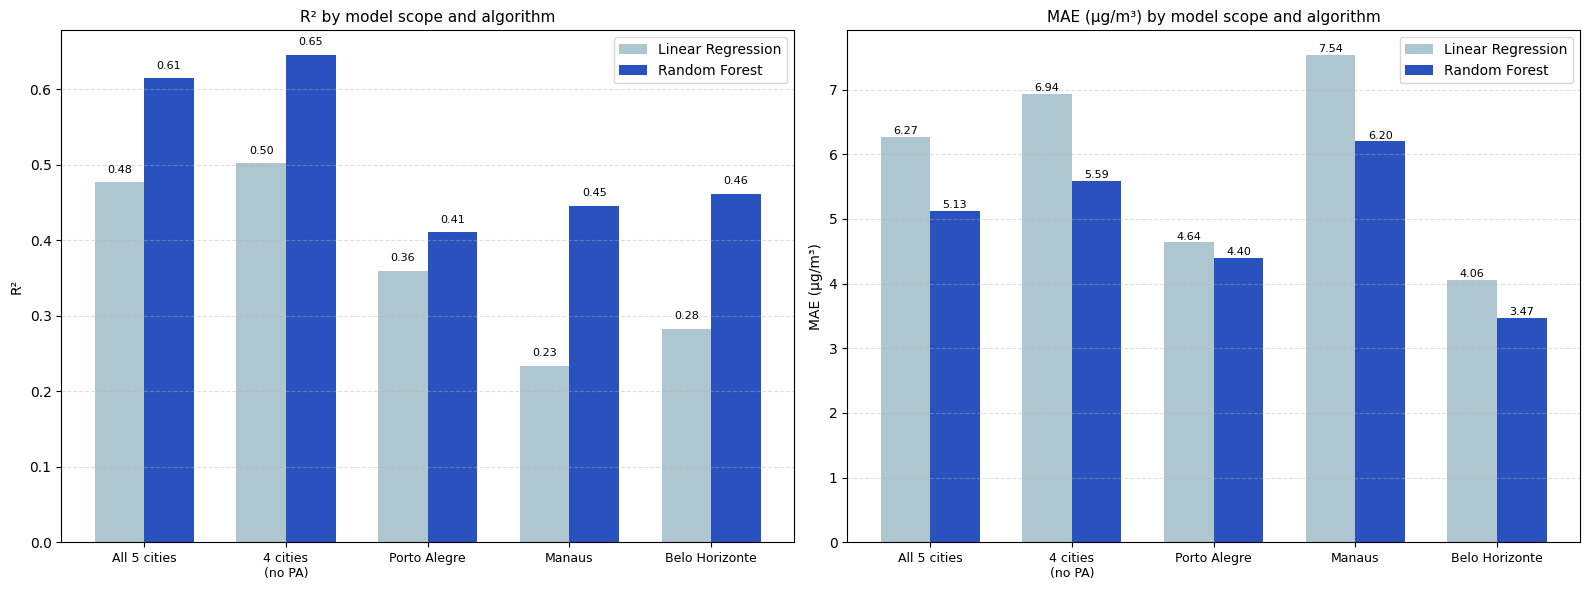

In [6]:
# ── Visual comparison — R² and MAE across all models ─────────────────────────
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

scope_order = ["all5", "4city", "porto_alegre", "manaus", "belo_horizonte"]
scope_labels = ["All 5 cities", "4 cities\n(no PA)", "Porto Alegre", "Manaus", "Belo Horizonte"]
x = range(len(scope_order))
width = 0.35

for ax, metric, title, ylabel in [
    (axes[0], "R²", "R² by model scope and algorithm", "R²"),
    (axes[1], "MAE (μg/m³)", "MAE (μg/m³) by model scope and algorithm", "MAE (μg/m³)"),
]:
    lr_vals = [results_df[(results_df["scope"] == s) &
               (results_df["algorithm"] == "LinearRegression")][metric].values[0]
               for s in scope_order]
    rf_vals = [results_df[(results_df["scope"] == s) &
               (results_df["algorithm"] == "RandomForest")][metric].values[0]
               for s in scope_order]

    bars1 = ax.bar([xi - width/2 for xi in x], lr_vals, width,
                   label="Linear Regression", color="#aec6cf")
    bars2 = ax.bar([xi + width/2 for xi in x], rf_vals, width,
                   label="Random Forest", color="#2a52be")

    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xticks(list(x))
    ax.set_xticklabels(scope_labels, fontsize=9)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # Add value labels on bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## Finding 1 — Random Forest consistently outperforms Linear Regression

- R² gap of 0.13–0.18 between RF and LR across all scopes
- Confirms non-linear relationships throughout — linear assumptions too simplistic
- 4city RF is the best overall model (R²=0.646) — removing Porto Alegre tightens fit
- All5 RF (R²=0.615) surprisingly competitive — city dummy absorbs PA baseline
- BH has lowest MAE (3.47 μg/m³) despite modest R² — narrow PM2.5 range
- Manaus has highest MAE (6.20 μg/m³) — fire spike variability hard to predict precisely

**MAE vs R² crossover (All5 vs 4city):**
- 4city has better R² but worse MAE than All5
- Including PA lowers average MAE because PA's low PM2.5 values are
  easy to predict accurately in absolute terms
- R² is the more meaningful metric here — measures explained variance

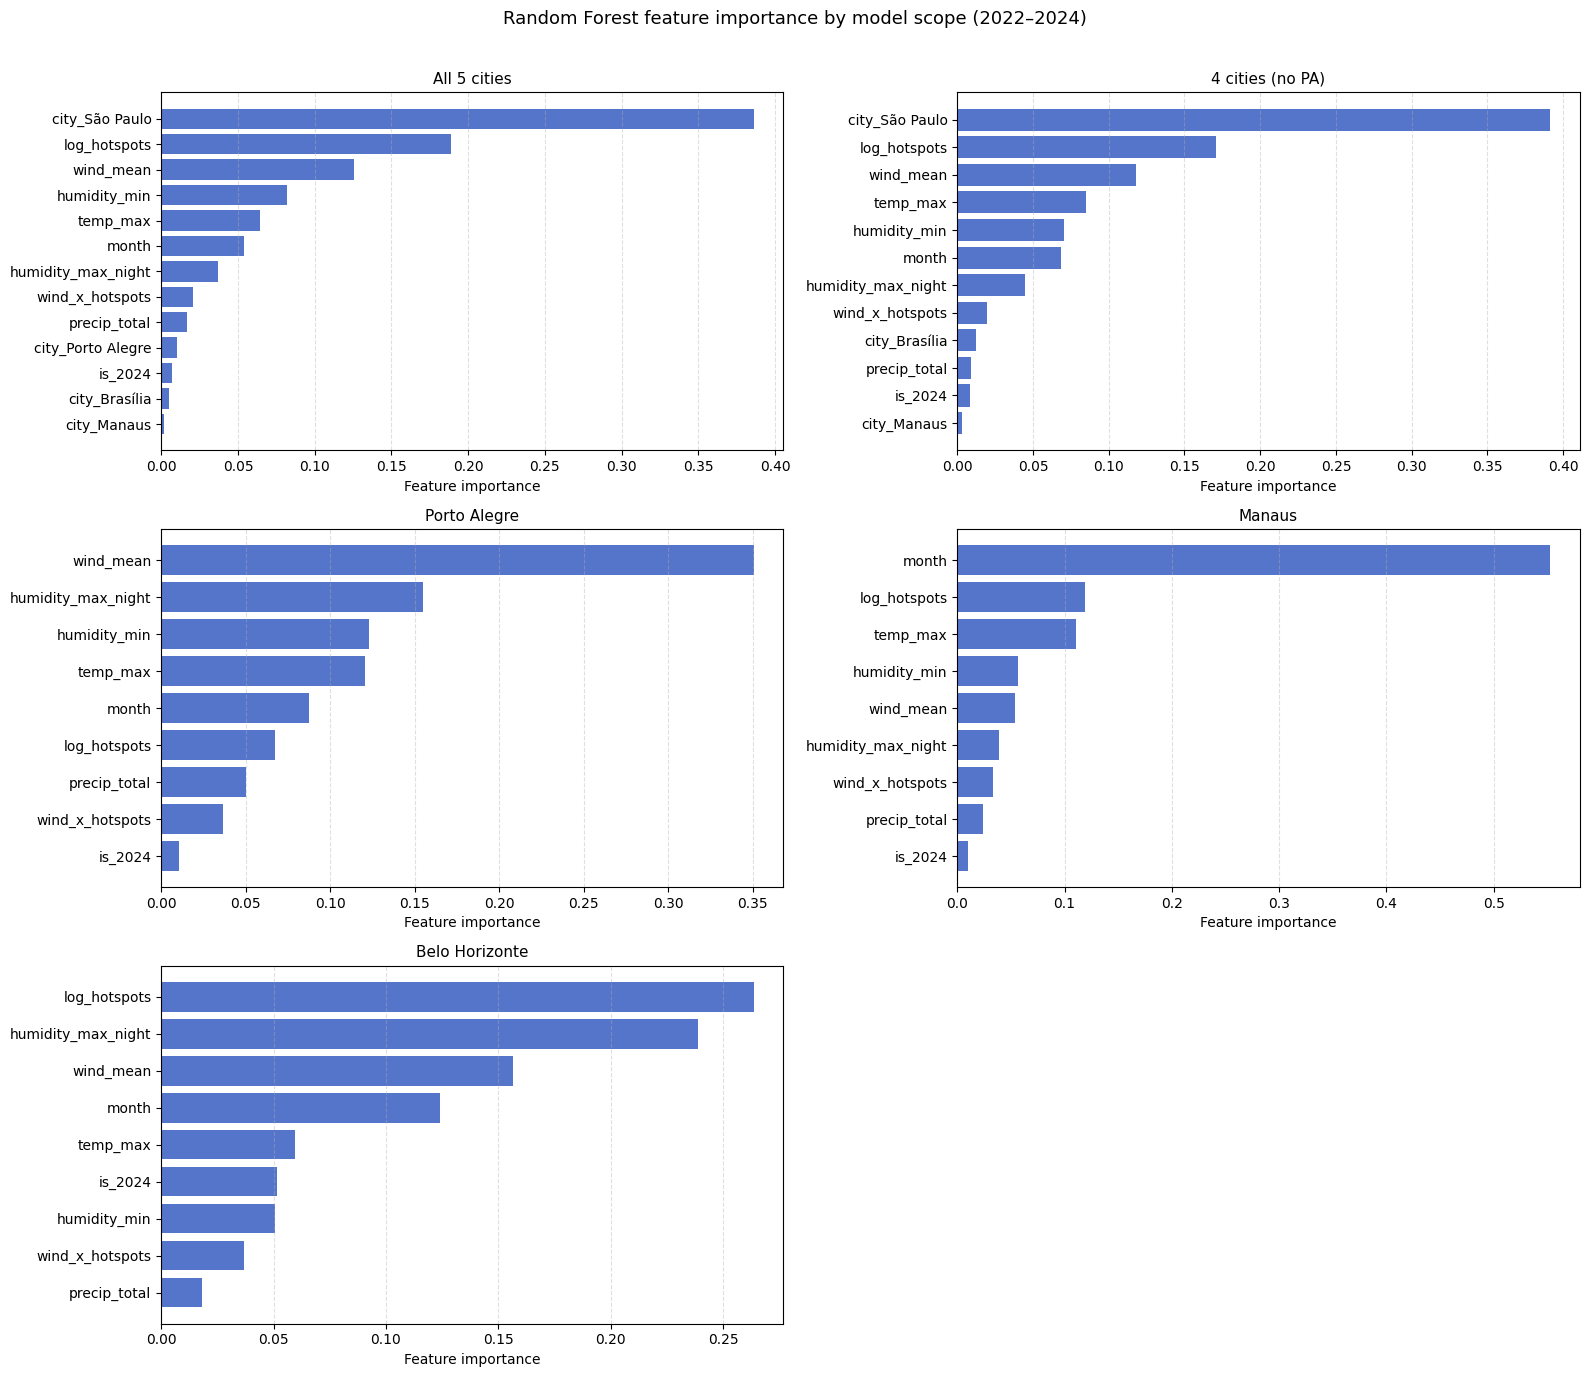

In [7]:
# ── Feature importance — Random Forest models ─────────────────────────────────
# Random Forest provides built-in feature importance scores
# Measures how much each feature reduces prediction error across all trees
# Only available for Random Forest — Linear Regression uses coefficients instead

# Extract RF results only
rf_results = [r for r in results if r["algorithm"] == "RandomForest"]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14))

scope_labels = {
    "all5": "All 5 cities",
    "4city": "4 cities (no PA)",
    "porto_alegre": "Porto Alegre",
    "manaus": "Manaus",
    "belo_horizonte": "Belo Horizonte",
}

for i, result in enumerate(rf_results):
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    # Get feature importances from trained RF model
    importances = result["model"].feature_importances_
    features = result["features"]

    # Sort by importance descending
    importance_df = pd.DataFrame({
        "feature": features,
        "importance": importances,
    }).sort_values("importance", ascending=True)

    # Horizontal bar chart — easier to read feature names
    ax.barh(
        importance_df["feature"],
        importance_df["importance"],
        color="#2a52be",
        alpha=0.8,
    )

    ax.set_title(scope_labels[result["scope"]], fontsize=11)
    ax.set_xlabel("Feature importance")
    ax.grid(axis="x", linestyle="--", alpha=0.4)

axes[2, 1].set_visible(False)

fig.suptitle(
    "Random Forest feature importance by model scope (2022–2024)",
    fontsize=13
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Finding 2 — Feature importance reveals city-specific PM2.5 drivers

**Multi-city models (All5, 4city):**
- city_São Paulo dominates (~0.39) — SP's chronic elevated baseline captured
  as a city-level offset rather than explained by weather or fire variables
- log_hotspots second (~0.17–0.18) — fire activity is the dominant
  explainable predictor across cities

**Porto Alegre:**
- Wind dominates (0.35) — captures frontal system dynamics not visible
  in linear correlation; non-linear effect missed by Pearson r
- More balanced feature distribution — no single dominant driver

**Manaus:**
- Month dominates (0.52) — seasonality more predictive than actual fire count
- State-level fire data too noisy — model learns "fire season = high PM2.5"
  rather than "more fires = more PM2.5"
- Confirms need for finer spatial resolution fire data for Manaus modeling

**Belo Horizonte:**
- log_hotspots (0.27) and humidity_max_night (0.24) co-equal top features
- Confirms integration EDA: fire activity and nighttime inversion trapping
  are the two dominant PM2.5 mechanisms in BH
- is_2024 flag matters for BH (0.05) — 2024 extreme spike unusual enough
  to require explicit flagging
- Wind appears with non-linear effect (0.16) not captured by Pearson r

**Key modeling insight:**
- City dummy absorbing SP baseline is both a finding and a limitation
- Month as dominant Manaus feature points to spatial resolution as the
  key improvement needed for future modeling iterations

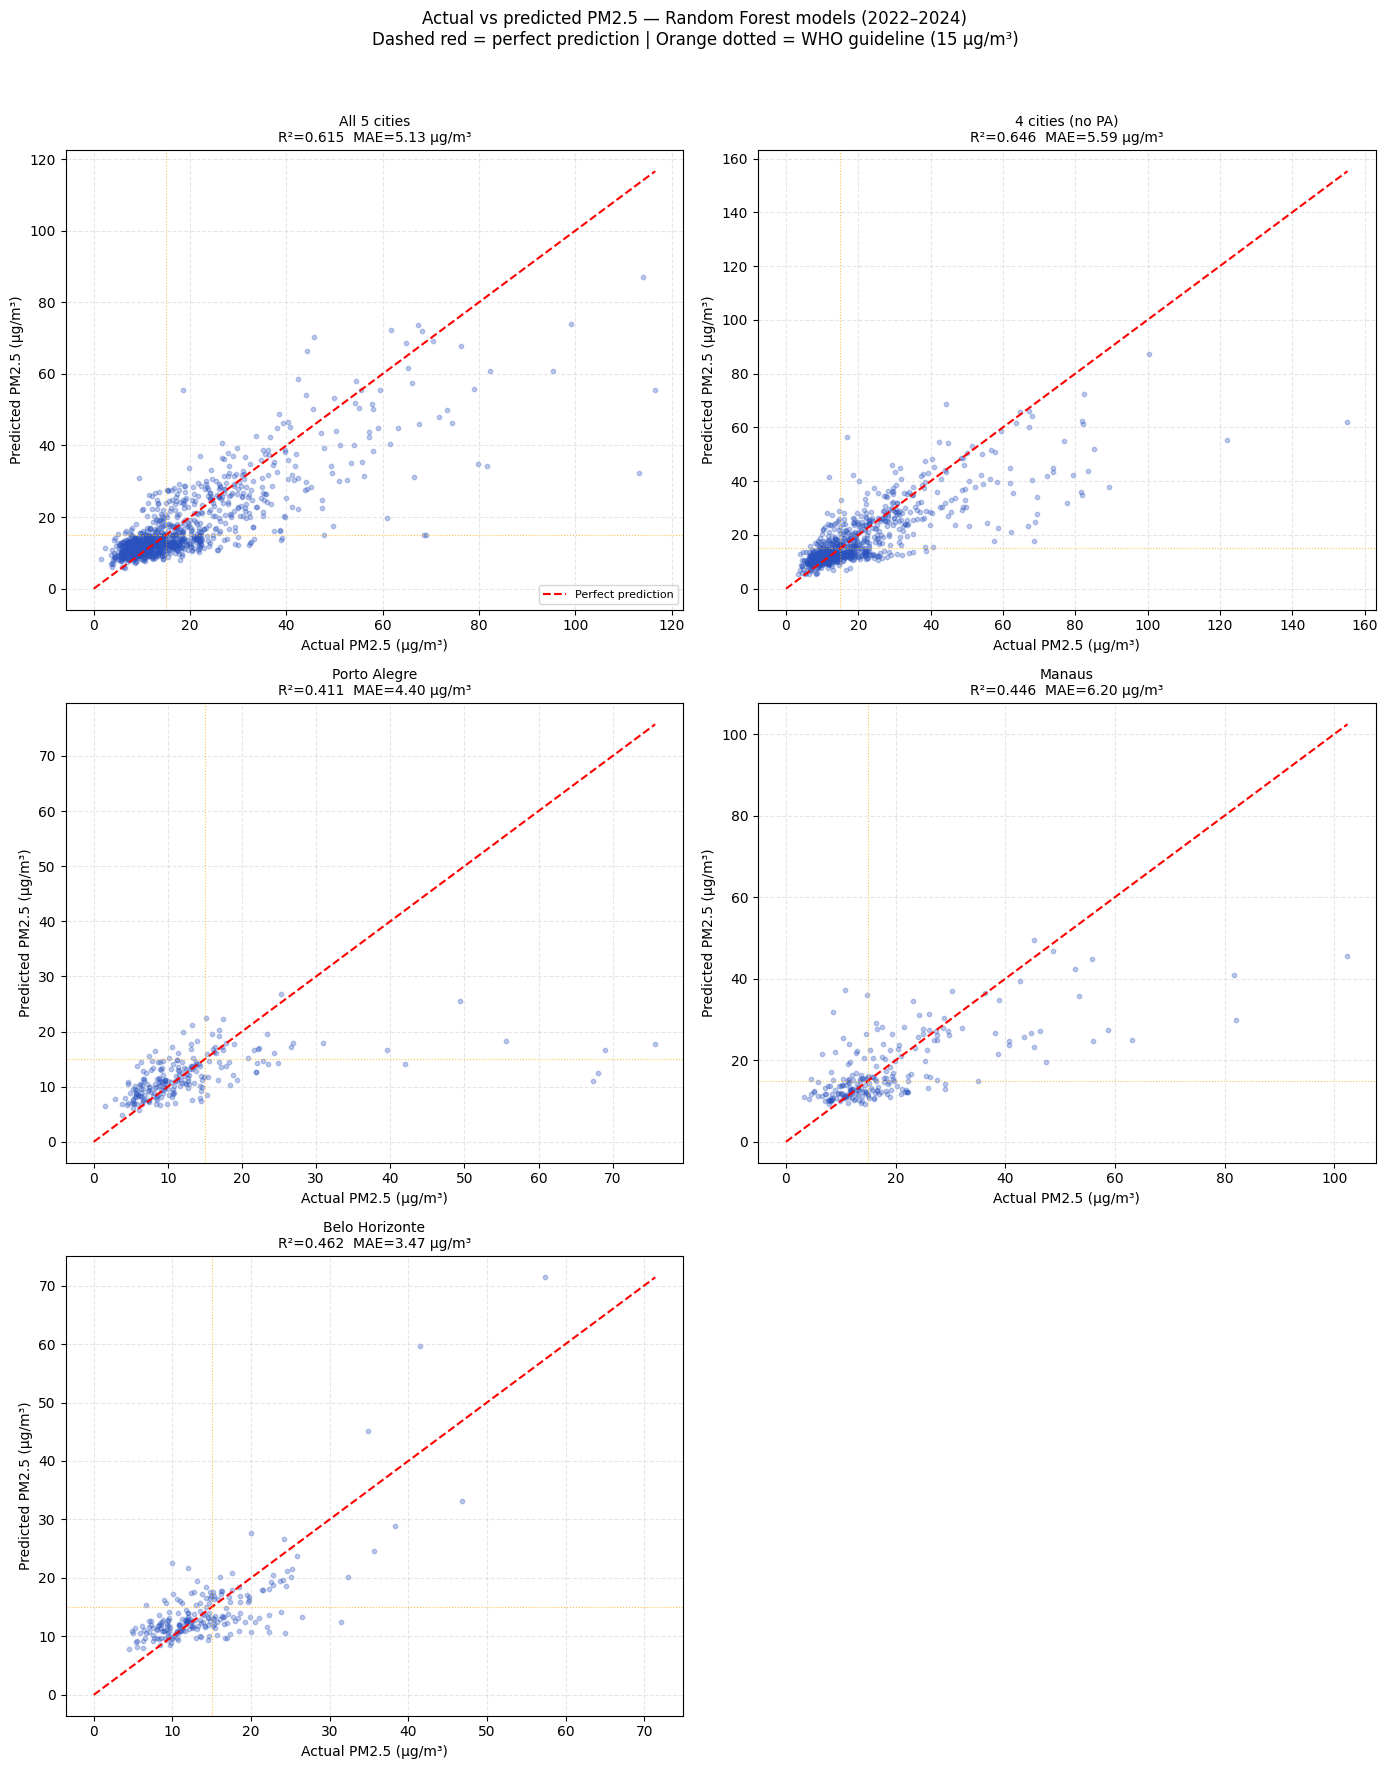

In [8]:
# ── Actual vs predicted plots — Random Forest models ─────────────────────────
# Shows how well each model's predictions align with actual PM2.5 values
# Points on the diagonal = perfect prediction
# Scatter above diagonal = underprediction, below = overprediction
# Back-transformed from log scale to original μg/m³ for interpretability

rf_results = [r for r in results if r["algorithm"] == "RandomForest"]

scope_labels = {
    "all5": "All 5 cities",
    "4city": "4 cities (no PA)",
    "porto_alegre": "Porto Alegre",
    "manaus": "Manaus",
    "belo_horizonte": "Belo Horizonte",
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 18))

for i, result in enumerate(rf_results):
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    # Back-transform from log scale to original PM2.5 units
    y_actual = np.exp(result["y_test"])
    y_pred = np.exp(result["y_pred"])

    # Scatter — actual vs predicted
    ax.scatter(
        y_actual,
        y_pred,
        alpha=0.3,
        s=10,
        color="#2a52be",
    )

    # Perfect prediction line — points should cluster around this
    max_val = max(y_actual.max(), y_pred.max())
    ax.plot(
        [0, max_val], [0, max_val],
        color="red",
        linewidth=1.5,
        linestyle="--",
        label="Perfect prediction",
    )

    # WHO PM2.5 guideline — vertical and horizontal reference
    ax.axvline(x=15, color="orange", linewidth=0.8, linestyle=":", alpha=0.7)
    ax.axhline(y=15, color="orange", linewidth=0.8, linestyle=":", alpha=0.7)

    ax.set_title(
        f"{scope_labels[result['scope']]}\n"
        f"R²={result['r2']:.3f}  MAE={result['mae_ugm3']:.2f} μg/m³",
        fontsize=10
    )
    ax.set_xlabel("Actual PM2.5 (μg/m³)")
    ax.set_ylabel("Predicted PM2.5 (μg/m³)")
    ax.grid(linestyle="--", alpha=0.3)

    if i == 0:
        ax.legend(fontsize=8)

axes[2, 1].set_visible(False)

fig.suptitle(
    "Actual vs predicted PM2.5 — Random Forest models (2022–2024)\n"
    "Dashed red = perfect prediction | Orange dotted = WHO guideline (15 μg/m³)",
    fontsize=12
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Finding 3 — Model fit varies by city; extremes consistently underpredicted

**All 5 cities and 4 cities:**
- Good fit in the typical range (5–30 μg/m³)
- Systematic underprediction above 40 μg/m³ — extreme fire season events
  are partially captured but compressed toward the mean
- 4city panel is cleaner — removing PA reduces scatter without losing signal

**Porto Alegre:**
- Good fit for typical days (5–20 μg/m³)
- Spike days (>20 μg/m³) plateau at ~15–20 μg/m³ predicted — model has no
  signal for PA extremes and defaults to the baseline
- Confirms the weak-signal conclusion from EDA and feature importance

**Manaus:**
- Systematic overprediction at low values (5–15 μg/m³ actual → 15–25 μg/m³ predicted)
- Systematic underprediction at extremes (80–100 μg/m³ actual → 30–45 μg/m³ predicted)
- Model biased toward fire season range — struggles with both clean and extreme days
- State-level fire data insufficient to capture the worst local smoke events

**Belo Horizonte:**
- Best-behaved scatter across all panels
- Compact, well-centered cluster from 5–25 μg/m³
- A few 2024 extreme events missed above 35 μg/m³ but overall most reliable model
- Confirms co-equal fire + inversion mechanisms give sufficient predictive signal

**Practical implications:**
- Models are production-ready for typical air quality prediction (5–30 μg/m³)
- Not suitable for predicting worst-case events — underpredicts health risk
  on the most dangerous days
- BH model most suitable for real-world use
- Manaus model needs finer spatial resolution fire data to improve